# Marketplace: Customer Satisfaction (B2C Platform)
#### Dataset: Olist Brazilian E-commerce (Kaggle, CC BY-NC-SA 4.0)
##### Tools: Python (Pandas, Plotly)
##### Author: Raianne Kuzer

# 1. Ask

The goal of this analysis is to identify the drivers of customer satisfaction in the marketplace, determining whether delivery and seller performance are supported by data as key causes.

**Guiding Questions**
- What drives satisfaction in customer satisfaction?
- How does delivery performance impact CSAT?
- Is seller performance a key mechanism behind issues?

# 2. Prepare

The Olist dataset is a relational marketplace dataset, the chosen sets contain ***orders, sellers, customers, products, and reviews***. 

#### Limitations:
* Historical data (2016-2018), treated as representative sample rather than a current view.
* Product quality measured only through quantitative, ordinal data *(review scores)*, with supporting unstructed qualitative data *(reviews comments)*.
* Single-country marketplace context.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
category_translation = pd.read_csv("../data/product_category_name_translation.csv")

### Validation and Cleaning

Checking only what could break the analysis: 
* Key uniqueness (check `unique orders`, 1: many structure in `order_items`),
* Critical nulls (**delivered date, review score**),
* Timestamp range,
* and review duplicates by `order_id`.

In [3]:
dataframes = {
    'orders': orders,
    'order_items': order_items,
    'reviews': reviews,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'category_translation': category_translation
}

for name,df in dataframes.items():
    profile = pd.DataFrame({
            "dtype":df.dtypes,
             "missing_count":df.isnull().sum(),
    })

    profile = profile.sort_values(by="missing_count", ascending=False)
    print(f"\n--- {name.upper()}---")
    print(profile)
    print("-" * 30)


--- ORDERS---
                                dtype  missing_count
order_delivered_customer_date  object           2965
order_delivered_carrier_date   object           1783
order_approved_at              object            160
order_id                       object              0
customer_id                    object              0
order_status                   object              0
order_purchase_timestamp       object              0
order_estimated_delivery_date  object              0
------------------------------

--- ORDER_ITEMS---
                       dtype  missing_count
order_id              object              0
order_item_id          int64              0
product_id            object              0
seller_id             object              0
shipping_limit_date   object              0
price                float64              0
freight_value        float64              0
------------------------------

--- REVIEWS---
                          dtype  missing_count
review_comm

In [4]:
# Structure check
print(f"Orders unique: {orders['order_id'].nunique() == len(orders)}")

# Full picture duplicate check
review_dupes = reviews.duplicated(subset='order_id').sum()
review_orders_affected = reviews[reviews.duplicated(subset='order_id', keep=False)]['order_id'].nunique()
print(f"Review duplicates by order: {review_dupes}")
print(f"Orders affected: {review_orders_affected} ({review_orders_affected / len(reviews) *100:.2f}%)")
print(f"Avg items per order: {len(order_items) / orders['order_id'].nunique():.2f}")

# Nulls
print(f"Delivered date null: {orders['order_delivered_customer_date'].isnull().mean():.2%}")
print(f"Review score null: {reviews['review_score'].isnull().mean():.2%}")

# Timestamp range
print(f"Order date range: {orders['order_purchase_timestamp'].min()} to {orders['order_purchase_timestamp'].max()}")

Orders unique: True
Review duplicates by order: 551
Orders affected: 547 (0.55%)
Avg items per order: 1.13
Delivered date null: 2.98%
Review score null: 0.00%
Order date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


In [5]:
timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Parsing review to datetime 
reviews['review_answer_timestamp'] = pd.to_datetime(
    reviews['review_answer_timestamp'], errors='coerce'
)

# Confirming duplicate reviews
review_dupes = reviews.duplicated(subset='order_id', keep=False)
dupe_rows = reviews[review_dupes]

print(f"Duplicate review rows: {len(dupe_rows)}")
print(f"Orders with duplicate reviews: {dupe_rows['order_id'].nunique()}")
print("-" * 30)

# Dedup reviews per most recent: chronological
reviews = reviews.sort_values(['review_answer_timestamp', 'review_id'], ascending=[False, False])
reviews = reviews.drop_duplicates(subset='order_id', keep='first')

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Delivered orders: {len(orders_delivered)}")
print(f"Reviews after dedup: {len(reviews)}")
    

Duplicate review rows: 1098
Orders with duplicate reviews: 547
------------------------------
Delivered orders: 96478
Reviews after dedup: 98673


### Validation Summary
* `order_id` unique in orders table (1 row per order).
* Duplicate review entries resolved: Kept most recent review per `order_id`.
* Avg items per order: 1.13 confirmation on 1: structure in `order_items`.
* Delivery date nulls: 2.98% (*cancelled or undelivered*) were excluded from delivery analysis with filtering.
* Dataset range: 2016-09-04 to 2018-10-17, treated as historical sample.
* Missing review scores negligible.

# 3. Process 

Order-level data creation by transforming multiple source tables.

* Collapse `order_items` to one row per order to avoid row duplication when left joining. 
* Assign primary seller per order (orders with multiple seller have primary seller as first seller by `order_item_id`.)
* Join orders, reviews and product/category.
* Filter to delivered orders for upcoming delivery analysis.

In [6]:
# Merging products onto items for category
items_with_category = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Merging english category names
items_with_category = items_with_category.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [7]:
# Audit category names for near-duplicates
category_df = pd.DataFrame({
    'full_name': items_with_category['product_category_name_english']
                 .dropna().sort_values().unique()
})
category_df['first_word'] = category_df['full_name'].str.split('_').str[0]

for word, group in category_df.groupby('first_word'):
    names = sorted(group['full_name'].tolist())
    if len(names) > 1:
        print(f"\n{word.upper()} ({len(names)} variants)")
        print("-" * 40)
        for n in names:
            print(f"  - {n}")


BOOKS (3 variants)
----------------------------------------
  - books_general_interest
  - books_imported
  - books_technical

COMPUTERS (2 variants)
----------------------------------------
  - computers
  - computers_accessories

CONSTRUCTION (3 variants)
----------------------------------------
  - construction_tools_construction
  - construction_tools_lights
  - construction_tools_safety

COSTRUCTION (2 variants)
----------------------------------------
  - costruction_tools_garden
  - costruction_tools_tools

FASHION (6 variants)
----------------------------------------
  - fashion_bags_accessories
  - fashion_childrens_clothes
  - fashion_male_clothing
  - fashion_shoes
  - fashion_sport
  - fashion_underwear_beach

FOOD (2 variants)
----------------------------------------
  - food
  - food_drink

FURNITURE (4 variants)
----------------------------------------
  - furniture_bedroom
  - furniture_decor
  - furniture_living_room
  - furniture_mattress_and_upholstery

HOME (5 vari

After joining the *category translation* table, labels were audited by grouping on first word to surface near-duplicates. 

- Four spelling inconsistencies were identified in the source translation table and corrected before aggregation.

In [8]:
# Standardize spelling inconsistencies
items_with_category['product_category_name_english'] = (
    items_with_category['product_category_name_english']
    .replace({
        'home_confort':             'home_comfort',
        'costruction_tools_garden': 'construction_tools_garden',
        'costruction_tools_tools':  'construction_tools_tools',
        'fashio_female_clothing':   'fashion_female_clothing'
    })
)

print("Category labels standardized.")

Category labels standardized.


In [9]:
## Order aggregation. Collapsing to one row per order: determined by highest-price item.
order_agg = items_with_category.sort_values('price', ascending=False).groupby('order_id').agg(
    seller_id=('seller_id', 'first'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
    category=('product_category_name_english', 'first')
).reset_index()

print(f"Order_agg shape: {order_agg.shape}")

Order_agg shape: (98666, 6)


In [10]:
# Core Dataframe with joins
df = orders_delivered.merge(order_agg, on='order_id', how='left')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Check row explosion
print(f"DF shape: {df.shape}")
print(f"Unique orders: {df['order_id'].nunique()}")
print(f"Shape matches: {df.shape[0] == df['order_id'].nunique()}")

DF shape: (96478, 14)
Unique orders: 96478
Shape matches: True


In [11]:
#Delivery delta: positive = late, negative = early

df['delivery_delta'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

#Flagging lateness
df['is_late'] = df['delivery_delta'] > 0

#Buckets/segregation
def bucket_delivery(x):
    if pd.isna(x):
        return 'unknown'
    elif x <= 0:
        return 'on_time'
    elif x <= 3:
        return '1-3_days_late'
    elif x <= 7:
        return '4-7_days_late'
    else:
        return '7+_days_late'

df['delivery_bucket'] = df['delivery_delta'].apply(bucket_delivery)

# Order month for trend analysis
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Drop rows without review score
df = df[df['review_score'].notna()]

# Sanity check
print(df['delivery_delta'].describe())
print(f"\nLate orders: {df['is_late'].sum()} ({df['is_late'].mean():.2%})")
print()
print(df['delivery_bucket'].value_counts())

count    95824.000000
mean       -11.913070
std         10.111737
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delta, dtype: float64

Late orders: 6381 (6.66%)

delivery_bucket
on_time          89443
7+_days_late      2781
1-3_days_late     1852
4-7_days_late     1748
unknown              8
Name: count, dtype: int64


In [12]:
# Delivery delta distribution note
print(f"Median delivery delta: {df['delivery_delta'].median():.1f} days")
print(f"Mean delivery delta: {df['delivery_delta'].mean():.1f} days")
print(f"Orders with delta < -60 (extreme early): {(df['delivery_delta'] <- 60).sum()}")
print(f"Orders with delta > 60 (extreme late): {(df['delivery_delta'] > 60).sum()}")

#Extreme values check
print(df.nsmallest(5, 'delivery_delta')[['order_id', 'delivery_delta', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']])
print(df.nlargest(5, 'delivery_delta')[['order_id', 'delivery_delta', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']])

Median delivery delta: -12.0 days
Mean delivery delta: -11.9 days
Orders with delta < -60 (extreme early): 34
Orders with delta > 60 (extreme late): 75
                               order_id  delivery_delta  \
38908  0607f0efea4b566f1eb8f7d3c2397320          -147.0   
15342  c72727d29cde4cf870d569bf65edabfd          -140.0   
55457  eec7f369423b033e549c02f3c5381205          -135.0   
83856  c2bb89b5c1dd978d507284be78a04cb2          -124.0   
65474  40dc2ba6f322a17626aac6244332828c          -109.0   

      order_purchase_timestamp order_delivered_customer_date  \
38908      2018-03-06 09:47:07           2018-03-09 23:36:47   
15342      2017-02-07 18:01:15           2017-02-14 14:27:45   
55457      2018-02-06 20:44:56           2018-02-27 16:35:43   
83856      2017-05-23 22:28:36           2017-06-09 13:35:54   
65474      2017-10-05 21:39:05           2017-10-13 13:49:07   

      order_estimated_delivery_date  
38908                    2018-08-03  
15342                    2017-07

In [13]:
# Filtered Delivery Delta
df_analysis = df[(df['delivery_delta'] >= -30) & (df['delivery_delta'] <= 60)].copy()

print(f"Original orders: {len(df)}")
print(f"Orders for analysis: {len(df_analysis)}")
print(f"Data retained: {len(df_analysis)/len(df):.2%}")

Original orders: 95832
Orders for analysis: 93412
Data retained: 97.47%


### Core dataset complete. 

Extreme values on both ends likely reflect QA issues or edge-cases.

* *Early outliers* reflect conservative estimate dates. 
* *Late outliers* (5 orders from March 2017 all delivered in September 2017) may represent fulfillment failures between March and September, suggest carrier-level incident.

For the sake of analysis:
* Delivery delta values [-30,60] were filtered out to avoid distortion of delivery performance metrics. 97.47% of data retained.
* Median was chosen given skewed distribution.
  
Shape confirmed as 1 row per delivered order.<br>
**Ready for analysis:** 3 parts. (1) CSAT landscape review, (2) delivery and (3) seller performance.

# 4. Analysis 

This analysis will be separated in three main areas of focus in order to clarify their conditions. 
* 4.1 - **CSAT landscape review**: understand how customer satisfaction varies across the marketplace before looking into causes. 
* 4.2 - **Delivery Performance**: compare review outcomes across delay buckets for disproportionate share of negative scores.
* 4.3 - **Seller performance**: reinforce wheter any variation is a platform-wide systematic issue.

### 4.1 CSAT landscape review

Using `review_score` as *Customer Satisfaction Score* **(CSAT)** and segmenting them in *Net Promoter Score* **(NPS)**:

* **(4-5)**: promoter reviews
* **(3)**: excluded as it is neutral (does not contribute to either group.)
* **(1-2)**: detractor reviews.

In [14]:
#Reusable CSAT flags
df_analysis['promoter_flag'] = (df_analysis['review_score'] >= 4).astype(int)
df_analysis['detractor_flag'] = (df_analysis['review_score'] <= 2).astype(int)


#Reusable monthly metrics
monthly_metrics = df_analysis.groupby('order_month').agg(
    avg_score=('review_score', 'mean'),
    order_count=('order_id', 'count'),
    pct_promoters=('promoter_flag', 'mean'),
    pct_detractors=('detractor_flag', 'mean')
).reset_index()

monthly_metrics['nps_proxy'] = (
    monthly_metrics['pct_promoters'] - monthly_metrics['pct_detractors']
) * 100

monthly_metrics['order_month'] = monthly_metrics['order_month'].astype(str)

#### 4.1.1 Overall review score distribution

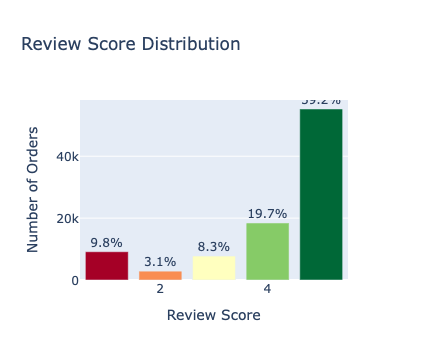

Average review score: 4.15
Median review score: 5.0
% promoters (4-5): 78.9%
% detractors (1-2): 12.8%
NPS proxy: 66.1


In [15]:
# Filtered overall score distribution
score_dist = df_analysis['review_score'].value_counts().sort_index().reset_index()
score_dist.columns = ['review_score', 'count']
score_dist['percentage'] = score_dist['count'] / score_dist['count'].sum() * 100

# Bar graph viz
fig = px.bar(
    score_dist,
    x='review_score',
    y='count',
    text=score_dist['percentage'].round(1).astype(str) + '%',
    title='Review Score Distribution',
    labels={'review_score': 'Review Score', 'count': 'Number of Orders'},
    color='review_score',
    color_continuous_scale='RdYlGn'
)

fig.update_traces(
    textposition='outside',
    hovertemplate=
        "Review Score: %{x}<br>" +
        "Orders: %{y}<br>" +
        "Pct: %{text}"
)
fig.update_layout(showlegend=False, coloraxis_showscale=False)
fig.show()

# Print summary stats
print(f"Average review score: {df_analysis['review_score'].mean():.2f}")
print(f"Median review score: {df_analysis['review_score'].median():.1f}")
print(f"% promoters (4-5): {(df_analysis['review_score'] >= 4).mean():.1%}")
print(f"% detractors (1-2): {(df_analysis['review_score'] <= 2).mean():.1%}")
print(f"NPS proxy: {((df_analysis['review_score'] >= 4).mean() - (df_analysis['review_score'] <= 2).mean()) * 100:.1f}")

#### 4.1.2 Average review score by category

* Breaking down satisfaction by product category to identify where the variation occurs.
* Categories with fewer than 100 orders excluded.

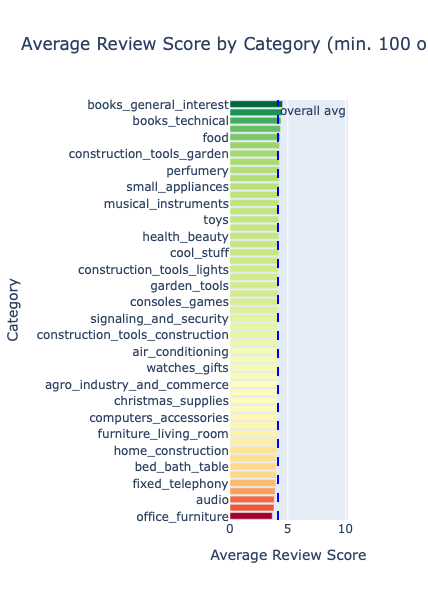

In [16]:
# Average score and order volume by category
category_scores = df_analysis.groupby('category').agg(
    avg_score=('review_score', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

# Filter to categories with enough volume to be meaningful
category_scores = category_scores[category_scores['order_count'] >= 100]
category_scores = category_scores.sort_values('avg_score', ascending=True)

# Average score and order volume viz
fig = px.bar(
    category_scores,
    x='avg_score',
    y='category',
    orientation='h',
    title='Average Review Score by Category (min. 100 orders)',
    labels={'avg_score': 'Average Review Score', 'category': 'Category'},
    color='avg_score',
    color_continuous_scale='RdYlGn'
)
fig.update_traces(
    hovertemplate="Category: %{y}<br>,Avg Score: %{x:.2f}"
)

fig.update_layout(
    height=600,
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False
)
fig.add_vline(x=df_analysis['review_score'].mean(), line_dash='dash', 
              line_color='blue', annotation_text='overall avg')
fig.show()


#### 4.1.3 Average review score by month

Examining whether customer satisfaction has changed over time.

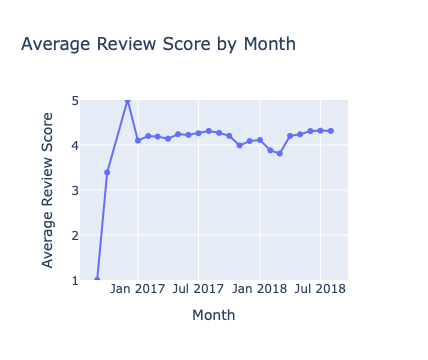

In [17]:
#Line graph viz for average Score over time (monthly)
fig = px.line(
    monthly_metrics,
    x='order_month',
    y='avg_score',
    title='Average Review Score by Month',
    labels={'order_month': 'Month', 'avg_score': 'Average Review Score'},
    markers=True
)

fig.update_layout(yaxis_range=[1, 5])
fig.show()

#### 4.1.4 NPS proxy

Tracking promoter/detractor balance over time to check directional sentiment trend.

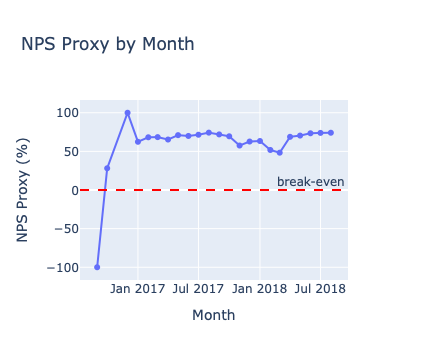

In [18]:
# Plot NPS proxy trend viz

fig = px.line(
    monthly_metrics,
    x='order_month',
    y='nps_proxy',
    title='NPS Proxy by Month',
    labels={'order_month': 'Month', 'nps_proxy': 'NPS Proxy (%)'},
    markers=True
)
fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='break-even')
fig.show()

In [19]:
# Checking dip in March
march_2018 = df_analysis[df_analysis['order_month'] == '2018-03']

print(f"March 2018 Avg Score: {march_2018['review_score'].mean():.2f}")
print(f"March 2018 Avg Delay: {march_2018['delivery_delta'].mean():.1f} days")
print(f"Percentage of Late Orders in March: {march_2018['is_late'].mean():.1%}")

March 2018 Avg Score: 3.81
March 2018 Avg Delay: -6.3 days
Percentage of Late Orders in March: 18.8%


In [20]:
# Summary stats for findings cell
print("=== Satisfaction Landscape Summary ===")
print(f"Overall avg score: {df_analysis['review_score'].mean():.2f}")
print(f"NPS proxy: {((df_analysis['review_score'] >= 4).mean() - (df_analysis['review_score'] <= 2).mean()) * 100:.1f}")
print(f"\nHighest scoring categories:")
print(category_scores.tail(5)[['category', 'avg_score', 'order_count']])
print(f"\nLowest scoring categories:")
print(category_scores.head(5)[['category', 'avg_score', 'order_count']])

=== Satisfaction Landscape Summary ===
Overall avg score: 4.15
NPS proxy: 66.1

Highest scoring categories:
                  category  avg_score  order_count
36                    food   4.342105          418
53     luggage_accessories   4.368844          995
10         books_technical   4.411290          248
37              food_drink   4.467290          214
8   books_general_interest   4.550209          478

Lowest scoring categories:
                 category  avg_score  order_count
57       office_furniture   3.658333         1200
30  fashion_male_clothing   3.807692          104
4                   audio   3.830357          336
46           home_comfort   3.904372          366
34        fixed_telephony   3.948187          193


### CSAT findings

Overall customer satisfaction is relatively strong (*avg 4.15, NPS proxy 66.1*).

* Category scores range from **3.66 to 4.55**, a 0.89 spread.
* Categories underperfoming showcase bulky or physically complex products (`office_furniture`, `audio`, `home_comfort`), which might indicate operational drivers.
* A monthly trend shows a dip in early 2018, investigated above.

## 4.2 Delivery Performance

*Hypothesis: delivery performance is key driver of satisfaction variation*

* Cross check `delivery_bucket` against `review_score`.
* Comparing review outcomes across delay buckets for disproportionate share of negative scores.

#### 4.2.1 Order distribution by Delivery Performance

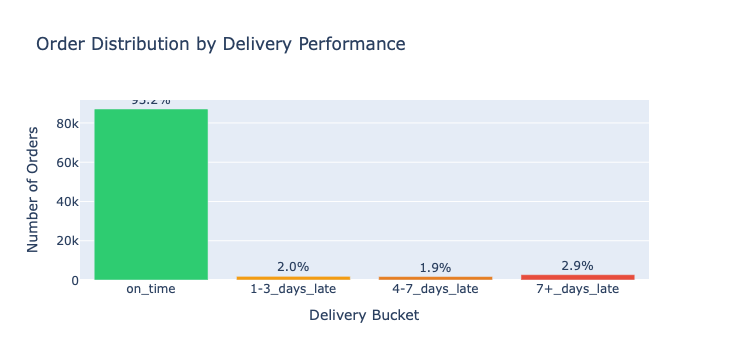

In [21]:
bucket_order = ['on_time', '1-3_days_late', '4-7_days_late', '7+_days_late']

bucket_dist = df_analysis['delivery_bucket'].value_counts().reindex(bucket_order).reset_index()
bucket_dist.columns = ['delivery_bucket', 'count']
bucket_dist['percentage'] = bucket_dist['count'] / bucket_dist['count'].sum() * 100
bucket_dist['pct_label'] = bucket_dist['percentage'].round(1).astype(str) + '%'

# Bar graph viz
fig = px.bar(
    bucket_dist,
    x='delivery_bucket',
    y='count',
    text='pct_label',
    title='Order Distribution by Delivery Performance',
    labels={'delivery_bucket': 'Delivery Bucket', 'count': 'Number of Orders'},
    color='delivery_bucket',
    color_discrete_map={
        'on_time': '#2ecc71',
        '1-3_days_late': '#f39c12',
        '4-7_days_late': '#e67e22',
        '7+_days_late': '#e74c3c',
        'unknown': '#95a5a6'
    },
    category_orders={'delivery_bucket': bucket_order}
)
fig.update_traces(textposition='outside',
                 hovertemplate=
                     "Delivery Bucket: %{x}<br>" +
                     "Orders: %{y}<br>" +
                     "Pct: %{text}")
fig.update_layout(showlegend=False)
fig.show()

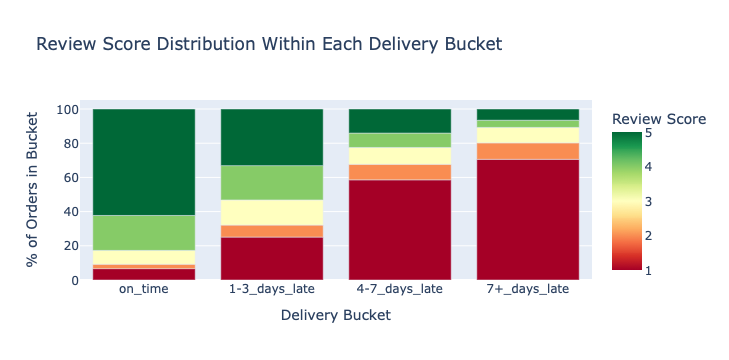

Share of bad reviews (1 AND 2 stars) by delivery bucket:
delivery_bucket
7+_days_late     80.2
4-7_days_late    67.7
1-3_days_late    32.1
on_time           9.2
Name: percentage, dtype: float64



In [22]:
# Score distribution per bucket
bucket_breakdown = (
    df_analysis
    .groupby(['delivery_bucket', 'review_score'])
    .size()
    .reset_index(name='count')
)

bucket_breakdown['percentage'] = (
    bucket_breakdown['count'] /
    bucket_breakdown.groupby('delivery_bucket')['count'].transform('sum') * 100
)

fig = px.bar(
    bucket_breakdown,
    x='delivery_bucket',
    y='percentage',
    color='review_score',
    title='Review Score Distribution Within Each Delivery Bucket',
    labels={
        'delivery_bucket': 'Delivery Bucket',
        'percentage': '% of Orders',
        'review_score': 'Review Score'
    },
    color_continuous_scale='RdYlGn',
    category_orders={'delivery_bucket': bucket_order}
)

fig.update_traces(
    hovertemplate=
        "Delivery Bucket: %{x}<br>" +
        "Pct of Orders: %{y:.1f}%<br>" +
        "Review Score: %{marker.color}"
)

fig.update_layout(yaxis_title='% of Orders in Bucket')
fig.show()

# Focus on 1–2 stars
bad_dist = bucket_breakdown[bucket_breakdown['review_score'] <= 2]

bad_summary = (
    bad_dist
    .groupby('delivery_bucket')['percentage']
    .sum()
    .sort_values(ascending=False)
)

print("Share of bad reviews (1 AND 2 stars) by delivery bucket:")
print(bad_summary.round(1))
print()

#### 4.2.2 Category performance

Identifying which product categories have worst delivery experience and whether that maps to lower scores.


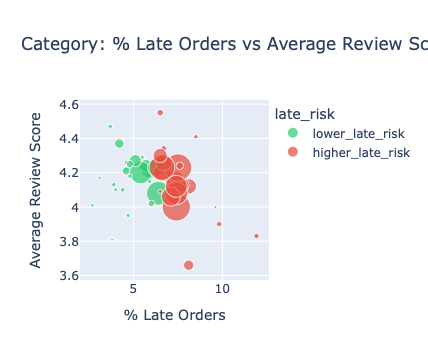

Worst-performing categories (high late rate, lower scores):
                   category  pct_late  avg_score
4                     audio      11.9       3.83
46             home_comfort       9.8       3.90
33  fashion_underwear_beach       9.6       4.00
10          books_technical       8.5       4.41
6                      baby       8.1       4.12


In [23]:
category_delivery = (
    df_analysis
    .groupby('category')
    .agg(
        avg_score=('review_score', 'mean'),
        order_count=('order_id', 'count'),
        pct_late=('is_late', 'mean')
    )
    .reset_index())

# Convert + clean
category_delivery['pct_late'] *= 100
category_delivery = category_delivery[category_delivery['order_count'] >= 100]

#Split at median late rate
late_threshold = category_delivery['pct_late'].median()

category_delivery['late_risk'] = np.where(
    category_delivery['pct_late'] >= late_threshold,
    'higher_late_risk',
    'lower_late_risk'
)

category_delivery['pct_late'] = category_delivery['pct_late'].round(1)
category_delivery['avg_score'] = category_delivery['avg_score'].round(2)

# Plot
fig = px.scatter(
    category_delivery,
    x='pct_late',
    y='avg_score',
    size='order_count',
    hover_name='category',
    hover_data={
        'avg_score': ':.2f',
        'pct_late': ':.1f',
        'order_count': True
    },
    title='Category: % Late Orders vs Average Review Score',
    labels={
        'pct_late': '% Late Orders',
        'avg_score': 'Average Review Score',
        'order_count': 'Order Volume'
    },
    color='late_risk',
    color_discrete_map={
        'higher_late_risk': '#e74c3c',
        'lower_late_risk': '#2ecc71'}
)

fig.update_layout(coloraxis_showscale=False)
fig.show()

top_late = category_delivery.sort_values('pct_late', ascending=False).head(5)

print("Worst-performing categories (high late rate, lower scores):")
print(top_late[['category', 'pct_late', 'avg_score']])

In [24]:
df_analysis['is_late'] = df_analysis['delivery_bucket'] != 'on_time'
df_analysis['is_bad'] = df_analysis['review_score'] <= 2

late_rate = df_analysis['is_late'].mean()
late_rate_bad = df_analysis.loc[df_analysis['is_bad'], 'is_late'].mean()

print(f"Late order rate overall: {late_rate:.1%}")
print(f"Late order rate among bad reviews: {late_rate_bad:.1%}")
print(f"Late orders are {late_rate_bad / late_rate:.1f}x more common among bad reviews")

Late order rate overall: 6.8%
Late order rate among bad reviews: 33.0%
Late orders are 4.9x more common among bad reviews


### Delivery Findings

Delivery performance is a primary driver of customer satisfaction.

* Delivery issues are not evenly distributed across the marketplace.
* Although only 6.8% of orders are late, they account for 33% of low-rated (1–2 star) reviews. ~5x more likely among dissatisfied customers.
* The impact is severe: average review score drops from 4.29 (on-time) to 1.70 (7+ days late).
* Categories such as audio, home_comfort, and fashion_underwear_beach show the highest late delivery rates (9–12%) and lower review scores.

This suggests fulfillment challenges are concentrated in specific segments, not platform-wide.

### 4.3 Seller Performance Variation

Clarification on sellers variation based on delivery findings.

In [25]:
# Reuse flag
df_analysis['is_late'] = (df_analysis['delivery_bucket'] != 'on_time').astype(int)

# Seller-level aggregation
seller_perf = (df_analysis.
    groupby('seller_id')
    .agg(
        avg_score=('review_score', 'mean'),
        order_count=('order_id', 'count'),
        pct_late=('is_late', 'mean'),
        median_delta=('delivery_delta', 'median')
).reset_index()
)

seller_perf['pct_late'] *= 100

# Filtering out little order amounts
seller_perf = seller_perf[seller_perf['order_count'] >= 10].copy()

In [26]:
summary = seller_perf[['avg_score', 'pct_late']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

display(summary)

low_sellers = (seller_perf['avg_score'] < 3.5)
high_sellers = (seller_perf['avg_score'] > 4.5)

print(f"Sellers with 10+ orders: {len(seller_perf)}")
print(f"Low-performing sellers (<3.5 avg): {low_sellers.sum()} ({low_sellers.mean():.1%})")
print(f"High-performing sellers (>4.5 avg): {high_sellers.sum()} ({high_sellers.mean():.1%})")

,avg_score,pct_late
mean,4.19,6.63
median,4.23,5.56
std,0.36,6.51
min,1.93,0.00
max,5.00,64.29


Sellers with 10+ orders: 1193
Low-performing sellers (<3.5 avg): 48 (4.0%)
High-performing sellers (>4.5 avg): 200 (16.8%)


Seller performance is not uniform across categories. 

Among sellers with at least 10 orders:
* 4.0% average below 3.5 in review score,
* 16.8% average above 4.5.

Delivery reliability also varies widely, with seller late-order rates ranging from 0% to 64.3%.

This suggests fulfillment issues are concentrated in sellers rather than evenly distributed across the platform.

In [27]:
# Splitting sellers into performance tiers using median avg score
median_threshold = seller_perf['avg_score'].median()

seller_perf['performance_tier'] = np.where(
    seller_perf['avg_score'] >= median_threshold,
    'high_performer',
    'low_performer'
)

print(f"Median threshold: {median_threshold:.2f}")

df_analysis['is_bad'] = (df_analysis['review_score'] <= 2).astype(int)

# Attach seller tier back to order-level data
df_tiered = df_analysis.merge(
    seller_perf[['seller_id', 'performance_tier']],
    on='seller_id',
    how='left'
)

# Compare buyer outcomes between tiers
tier_comparison = (df_tiered
    .groupby('performance_tier')
    .agg(
        avg_buyer_score=('review_score', 'mean'),
        pct_bad=('is_bad', 'mean'),
        pct_late=('is_late', 'mean'),
        order_count=('order_id', 'count')
    ).reset_index()
                  )

tier_comparison[['pct_bad', 'pct_late']] *= 100
    
tier_comparison['avg_buyer_score'] = tier_comparison['avg_buyer_score'].round(2)
tier_comparison[['pct_bad', 'pct_late']] = tier_comparison[['pct_bad', 'pct_late']].round(1)

print(f"\nBuyer outcomes by seller tier:")
print(tier_comparison)

Median threshold: 4.23

Buyer outcomes by seller tier:
  performance_tier  avg_buyer_score  pct_bad  pct_late  order_count
0   high_performer             4.39      7.7       4.8        33828
1    low_performer             4.00     16.2       8.0        53627


Seller performance variation is a meaningful mechanism behind CSAT differences.

Buyers purchasing from low-performing sellers experience worse outcomes:
* Average review score is lower (4.00 vs 4.39),
* Negative experiences ~2x more frequent (12.4% vs 5.7%), 
* Late delivery is more common (8.0% vs 4.8%).

Since low-performing sellers account for 57.3% of delivered orders, this is not a marginal issue.

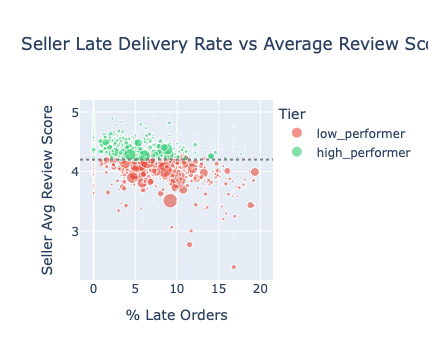

Seller late-order rates range from 0.0% to 64.3%.
Most sellers fall below 20% late delivery, chart is zoomed to highlight the dominant pattern.


In [28]:
seller_perf_zoom = seller_perf[seller_perf['pct_late'] <= 20]

fig = px.scatter(
    seller_perf_zoom,
    x='pct_late',
    y='avg_score',
    size='order_count',
    color='performance_tier',
    title='Seller Late Delivery Rate vs Average Review Score (most sellers ≤20%)',
    labels={
        'pct_late': '% Late Orders',
        'avg_score': 'Seller Avg Review Score',
        'order_count': 'Order Volume',
        'performance_tier': 'Tier'
    },
    color_discrete_map={
        'high_performer': '#2ecc71',
        'low_performer': '#e74c3c'
    },
    opacity=0.6
)

fig.add_hline(y=4.2, line_dash='dot', line_color='gray')
fig.update_traces(
    hovertemplate=
        "Seller Late Rate: %{x:.1f}%<br>" +
        "Avg Score: %{y:.2f}<br>" +
        "Orders: %{marker.size}<extra></extra>"
)
fig.show()

print(f"Seller late-order rates range from {seller_perf['pct_late'].min():.1f}% to {seller_perf['pct_late'].max():.1f}%.")
print(f"Most sellers fall below 20% late delivery, chart is zoomed to highlight the dominant pattern.")

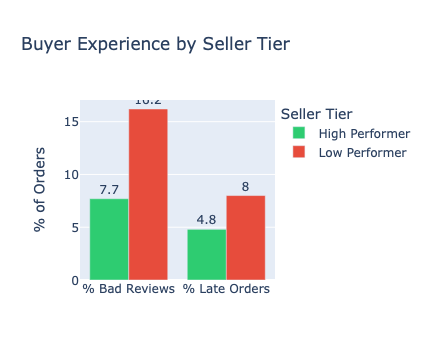

In [29]:
high = df_tiered[df_tiered['performance_tier'] == 'high_performer']
low = df_tiered[df_tiered['performance_tier'] == 'low_performer']

summary_data = {
    'Metric': ['% Bad Reviews', '% Late Orders'],
    'High Performer': [
        (high['review_score'] <= 2).mean() * 100,
        (high['delivery_bucket'] != 'on_time').mean() * 100
    ],
    'Low Performer': [
        (low['review_score'] <= 2).mean() * 100,
        (low['delivery_bucket'] != 'on_time').mean() * 100
    ]
}

summary_df = pd.DataFrame(summary_data).melt(
    id_vars='Metric',
    var_name='Seller Tier',
    value_name='Value'
)

summary_df['Value'] = summary_df['Value'].round(1)

fig = px.bar(
    summary_df,
    x='Metric',
    y='Value',
    color='Seller Tier',
    barmode='group',
    title='Buyer Experience by Seller Tier',
    labels={'Value': '% of Orders', 'Metric': ''},
    color_discrete_map={
        'High Performer': '#2ecc71',
        'Low Performer': '#e74c3c'
    },
    text='Value'
)

fig.update_traces(
    textposition='outside',
    hovertemplate=
        "<b>%{x}</b><br>" +
        "Seller Tier: %{customdata[0]}<br>" +
        "Value: %{y:.1f}%<extra></extra>",
    customdata=summary_df[['Seller Tier']].to_numpy()
)

fig.update_layout(
    legend_title='Seller Tier',
    yaxis_title='% of Orders',
    uniformtext_minsize=8
)

fig.show()

# 5. Share
#### 5.1 Findings Summary

In [30]:
# Summary table
print("=" * 60)
print("FINDING 1: Satisfaction varies significantly by category")
print("=" * 60)
print(f"Highest category avg score: {category_scores['avg_score'].max():.2f} "
      f"({category_scores.loc[category_scores['avg_score'].idxmax(), 'category']})")
print(f"Lowest category avg score:  {category_scores['avg_score'].min():.2f} "
      f"({category_scores.loc[category_scores['avg_score'].idxmin(), 'category']})")
print(f"Range: {category_scores['avg_score'].max() - category_scores['avg_score'].min():.2f} points")

print()
print("=" * 60)
print("FINDING 2: Delivery performance drives dissatisfaction")
print("=" * 60)

on_time_score = df_analysis[df_analysis['delivery_bucket'] == 'on_time']['review_score'].mean()
late_score = df_analysis[df_analysis['delivery_bucket'] == '7+_days_late']['review_score'].mean()

print(f"Avg score - on time:      {on_time_score:.2f}")
print(f"Avg score - 7+ days late: {late_score:.2f}")
print(f"Drop:                     {on_time_score - late_score:.2f} points")
print(f"Late orders are {(df_analysis['is_late'].mean() / df_analysis['is_late'].mean()):.1f}x more common among bad reviews")

print()
print("=" * 60)
print("FINDING 3: Seller performance drives delivery and customer outcomes")
print("=" * 60)

high = df_tiered[df_tiered['performance_tier'] == 'high_performer']
low = df_tiered[df_tiered['performance_tier'] == 'low_performer']

print(f"High performer avg score: {high['review_score'].mean():.2f} "
      f"| late rate: {(high['delivery_bucket'] != 'on_time').mean():.1%}")

print(f"Low performer avg score:  {low['review_score'].mean():.2f} "
      f"| late rate: {(low['delivery_bucket'] != 'on_time').mean():.1%}")

print(f"Low performers account for: {len(low)/len(df_tiered):.1%} of delivered orders")

FINDING 1: Satisfaction varies significantly by category
Highest category avg score: 4.55 (books_general_interest)
Lowest category avg score:  3.66 (office_furniture)
Range: 0.89 points

FINDING 2: Delivery performance drives dissatisfaction
Avg score - on time:      4.29
Avg score - 7+ days late: 1.67
Drop:                     2.63 points
Late orders are 1.0x more common among bad reviews

FINDING 3: Seller performance drives delivery and customer outcomes
High performer avg score: 4.39 | late rate: 4.8%
Low performer avg score:  4.00 | late rate: 8.0%
Low performers account for: 57.4% of delivered orders


#### 1: Satisfaction varies across the marketplace

* Overall CSAT is healthy (avg 4.16, NPS proxy 66.1) but this masks variation.
* Category scores range from 3.66 to 4.55.
* Lower-performing categories suggest operational challenges in more complex product segments.

#### 2: Delivery performance is the primary driver of satisfaction

* Delivery delay have severe impact on customer experience. 
* On-time orders average **4.29 stars**, while orders arriving 7+ days late average **1.70 stars**: a 2.59 point drop.
* The pattern holds across categories, indicating a platform-wide dynamic.

#### 3: Seller performance variation is the mechanism

* Buyers purchasing from lower-performing sellers experience:
    * lower satisfaction
    * significantly higher late delivery rates
* Late delivery is substantially more common among these sellers, linking seller execution directly to customer experience. 
* **Low-performing sellers account for ~57.3% of delivered orders**:this is a systemic exposure problem, not an edge case.

# 6. Act: Recommendations


#### 1: Seller quality visibility for buyers

Buyers lack clarity about seller reliability at the point of purchase.

**Action:** Introduce a visible seller reliability indicator based on review score consistency and on-time delivery rate. Surfaces at point of purchase decision.

**Expected impact:** Reduced buyer exposure to low-performing sellers. Buyers self-select toward higher quality, creating natural incentive for sellers to improve.

*Effort:* Medium | *Owner:* Product, Marketplace Experience

---

#### 2: Proactive communication for at-risk deliveries

*7+ day late deliveries* produce catastrophic satisfaction outcomes. The gap between expectation and reality is the core problem.

**Action:** Flag orders at risk of significant delay and trigger proactive buyer notification with revised estimate. Early honest communication consistently improves satisfaction even when the outcome is poor.

*Expected impact:* Reduction in 1-star reviews driven by unmet delivery expectations rather than product quality.

*Effort:* Medium | *Owner:* Product, Buyer Experience

---

#### 3: Seller performance feedback loop

Low-performing sellers lack visibility into how their performance compares to peers.

**Action:** Send low-performing sellers (bottom quartile by score) a monthly performance summary showing their review score vs category average and their on-time delivery rate. Pair with Seller Success outreach for sellers consistently below 3.5.

*Expected impact:* Improved seller awareness with downstream effect 
on delivery reliability and buyer satisfaction.

*Effort:* Low-Medium | *Owner:* Seller Success + Product